## LAB TASKS
1. Load a dataset for classification (e.g., Titanic, Breast Cancer dataset).
2. Apply data preprocessing (handle missing values, encode categorical data).
3. Split the dataset into training and testing sets.
4. Train a Random Forest Classifier on the training data.
5. Make predictions on the test set.
6. Evaluate performance using accuracy, precision, recall, and F1-score.
7. Visualize the Confusion Matrix
8. Compare with a Single Decision Tree

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
print("Loading Titanic dataset from OpenML...")
titanic = fetch_openml("titanic", version=1, as_frame=True, parser="auto")
df = titanic.frame

Loading Titanic dataset from OpenML...


In [2]:
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
target = "survived"
df = df[features + [target]].copy()
# Target comes as string/category ('0' or '1') — convert to int
df[target] = df[target].astype(int)

In [3]:
df["age"] = df["age"].fillna(df["age"].median())
df["fare"] = df["fare"].fillna(df["fare"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["sex"] = df["sex"].map({"male": 0, "female": 1}).astype(int)
df = pd.get_dummies(df, columns=["embarked"], drop_first=True, dtype=int)
X = df.drop(columns=[target])
y = df[target]

print("\n--- Preprocessed Data Head ---")
print(X.head())


--- Preprocessed Data Head ---
   pclass  sex      age  sibsp  parch      fare  embarked_Q  embarked_S
0       1    1  29.0000      0      0  211.3375           0           1
1       1    0   0.9167      1      2  151.5500           0           1
2       1    1   2.0000      1      2  151.5500           0           1
3       1    0  30.0000      1      2  151.5500           0           1
4       1    1  25.0000      1      2  151.5500           0           1


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [5]:
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf)
rf_rec = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("\n--- Random Forest Evaluation ---")
print(f"Accuracy:  {rf_acc:.4f}")
print(f"Precision: {rf_prec:.4f}")
print(f"Recall:    {rf_rec:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


--- Random Forest Evaluation ---
Accuracy:  0.7786
Precision: 0.7019
Recall:    0.7300
F1-Score:  0.7157

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.81      0.82       162
           1       0.70      0.73      0.72       100

    accuracy                           0.78       262
   macro avg       0.77      0.77      0.77       262
weighted avg       0.78      0.78      0.78       262



In [6]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt)
dt_rec = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

In [7]:
comparison_df = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
        "Decision Tree": [dt_acc, dt_prec, dt_rec, dt_f1],
        "Random Forest": [rf_acc, rf_prec, rf_rec, rf_f1],
    }
).round(4)

print("\n--- Model Comparison: Decision Tree vs. Random Forest ---")
print(comparison_df.to_string(index=False))


--- Model Comparison: Decision Tree vs. Random Forest ---
   Metric  Decision Tree  Random Forest
 Accuracy         0.7786         0.7786
Precision         0.7143         0.7019
   Recall         0.7000         0.7300
 F1-Score         0.7071         0.7157


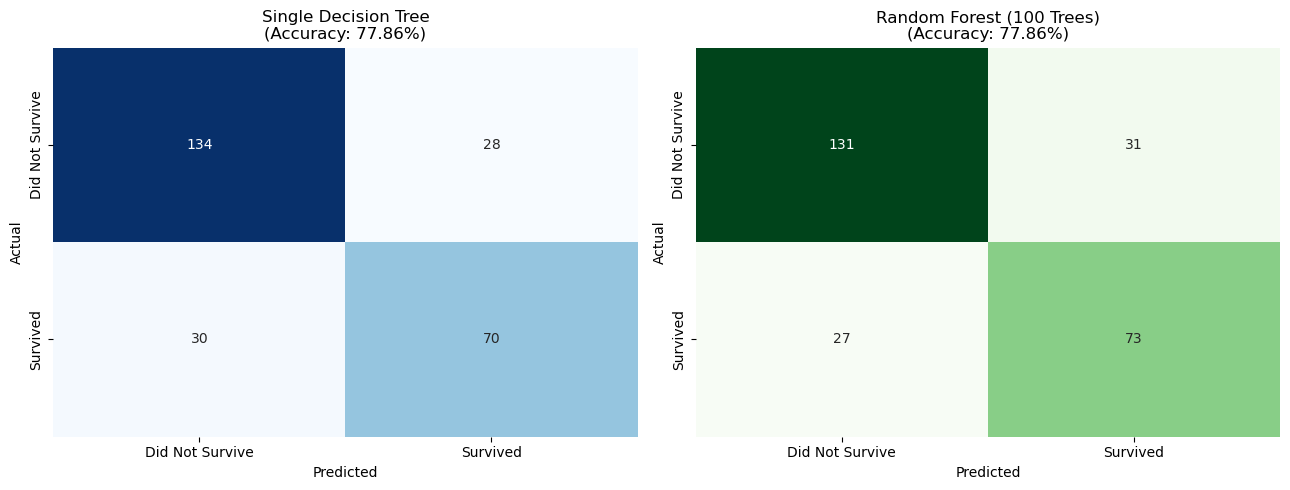

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    cbar=False,
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"],
)
axes[0].set_title(f"Single Decision Tree\n(Accuracy: {dt_acc:.2%})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1],
    cbar=False,
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"],
)
axes[1].set_title(f"Random Forest (100 Trees)\n(Accuracy: {rf_acc:.2%})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

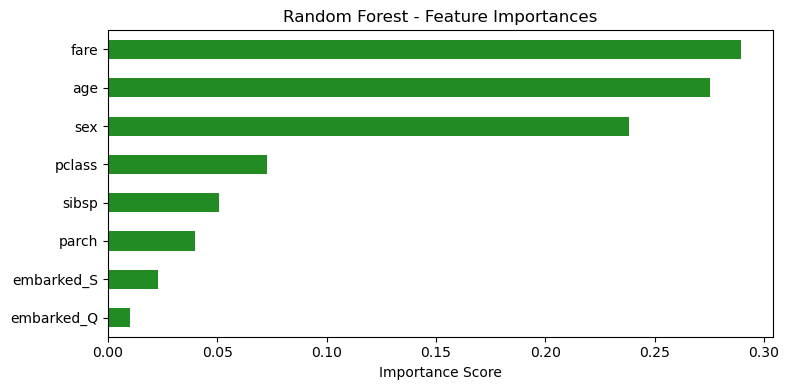

In [9]:
plt.figure(figsize=(8, 4))
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()
importances.plot(kind="barh", color="forestgreen")
plt.title("Random Forest - Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()